In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('../data/sp500_features.csv', index_col=0, parse_dates=True)
data.head()

,Close,High,Low,Open,Volume,log_return,realized_volatility_5,realized_volatility_18,realized_volatility_21,return_lag_1,return_lag_2,return_lag_3,return_lag_5,volume_change,volume_ma_5,day_of_week,month,future_volatility_21
Date,,,,,,,,,,,,,,,,,,
2015-02-03,2050.030029,2050.300049,2022.709961,2022.709961,4615900000,0.014336,0.224067,0.173837,0.180978,0.012879,-0.013077,0.009490,-0.013478,0.151577,4.277510e+09,1,2,0.078070
2015-02-04,2041.510010,2054.739990,2036.719971,2048.860107,4141920000,-0.004165,0.190170,0.160776,0.169203,0.014336,0.012879,-0.013077,-0.013588,-0.102684,4.292388e+09,2,2,0.093172
2015-02-05,2062.520020,2063.550049,2043.449951,2043.449951,3821990000,0.010239,0.191629,0.162386,0.168782,-0.004165,0.014336,0.012879,0.009490,-0.077242,4.231358e+09,3,2,0.087412
2015-02-06,2055.469971,2072.399902,2049.969971,2062.280029,4232970000,-0.003424,0.143511,0.159621,0.165366,0.010239,-0.004165,0.014336,-0.013077,0.107530,4.164222e+09,4,2,0.105841
2015-02-09,2046.739990,2056.159912,2041.880005,2053.469971,3549540000,-0.004256,0.143120,0.160259,0.153966,-0.003424,0.010239,-0.004165,0.012879,-0.161454,4.072464e+09,0,2,0.105036


In [2]:
feature_cols = ['realized_volatility_5', 'realized_volatility_18', 'realized_volatility_21',
                'volume_ma_5', 'month']

x = data[feature_cols]
y = data['future_volatility_21']

print(x.shape, y.shape)

(2724, 5) (2724,)


In [3]:
split_idx = int(len(x) * 0.8)

x_train = x.iloc[:split_idx]
x_test = x.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train: {x_train.shape[0]} rows ({x_train.index.min()} to {x_train.index.max()})")
print(f"Test: {x_test.shape[0]} rows ({x_test.index.min()} to {x_test.index.max()})")

Train: 2179 rows (2015-02-03 00:00:00 to 2023-09-28 00:00:00)
Test: 545 rows (2023-09-29 00:00:00 to 2025-12-01 00:00:00)


In [4]:
# Baseline prediction
naive_prediction = x_test['realized_volatility_21']
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_prediction))
naive_mae = mean_absolute_error(y_test, naive_prediction)

print(f"Naive baseline prediction - RMSE: {naive_rmse:.4f}, MAE: {naive_mae:.4f}")

Naive baseline prediction - RMSE: 0.0906, MAE: 0.0568


In [5]:
# Linear regression
model=LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print(f"Linear regression - RMSE: {lr_rmse:.4f}, MAE: {lr_mae:.4f}, R2: {lr_r2:.4f}")


Linear regression - RMSE: 0.0730, MAE: 0.0501, R2: 0.0924


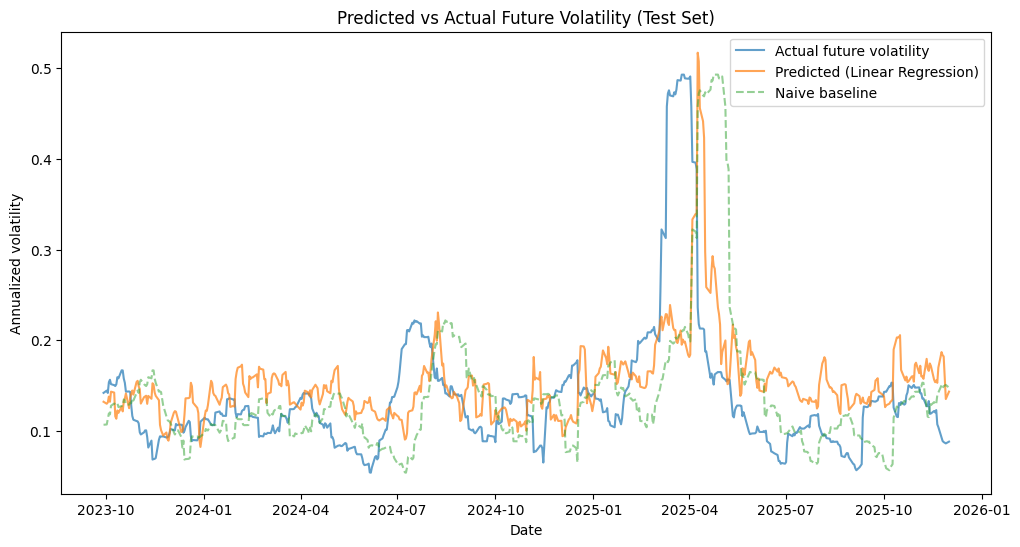

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual future volatility', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted (Linear Regression)', alpha=0.7)
plt.plot(y_test.index, naive_prediction, label='Naive baseline', alpha=0.5, linestyle='--')
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.title('Predicted vs Actual Future Volatility (Test Set)')
plt.legend()
plt.show()

In [7]:
coef_df = pd.DataFrame({'feature_cols': feature_cols, 
                        'coefficient': model.coef_})
print(coef_df.sort_values('coefficient', ascending=False))

             feature_cols   coefficient
1  realized_volatility_18  3.038071e-01
0   realized_volatility_5  2.805105e-01
3             volume_ma_5  1.743589e-11
4                   month -2.262379e-03
2  realized_volatility_21 -1.499615e-01


## Summary

Built a naive baseline and a linear regression model to forecast 21-day future realized
volatility, using a chronological 80/20 train-test split (test set: Sep 2023 – Dec 2025) to
avoid look-ahead bias.

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Naive baseline (last realized vol = future vol) | 0.0906 | 0.0568 | — |
| Linear Regression | 0.0730 | 0.0501 | 0.0924 |

**Key findings:**

- Linear Regression improves RMSE by ~19% and MAE by ~12% over the naive baseline, confirming
  the engineered features carry real predictive signal beyond simply repeating the last known
  volatility.
- R² = 0.092 means the model explains only ~9% of the variance in future volatility — low in
  absolute terms, but consistent with the generally low predictability of financial markets
  (also reflected in the non-normality and fat tails confirmed in Day 1).
- Model coefficients reveal multicollinearity among the three realized volatility windows:
  `realized_volatility_18` (0.304) and `realized_volatility_5` (0.281) carry positive weight,
  while `realized_volatility_21` is *negative* (-0.150) — the model is netting out redundant
  information across overlapping windows rather than each window contributing independently.
- `volume_ma_5` has an effectively zero coefficient (~1.7e-11) despite a 0.41 correlation with
  the target in Day 3 — its predictive information appears to be fully absorbed by the
  volatility features once combined in a multivariate model.

This motivates testing tree-based models (Random Forest, XGBoost) in next part of project, which are more
robust to multicollinearity and may better capture non-linear interactions between features.